# FR_extra — the full-retrieval (FR) results section, isolated

This notebook is the **capstone retrieval-results section (§16)** split out of
`riccati_solver_VOCALS_retrieval.ipynb` so it can be re-run against the canonical FR bundle
without executing the main notebook. It consumes:

* **`../../canon_ve046tik_FR_14July26/`** (or `runs/_ve046_tik_fr_parts/` on the cluster) — the
  **canonical ve046tik config-A sidecars** (125 profiles, consolidated 2026-07-14; see
  `hpc/FINAL_RESULTS_MANIFEST.md`, "ve046 campaign"). *Unless otherwise stated, no other FR
  results are to be used.*
* `scripts/retrieval_analysis.py` — the post-hoc metric suite (τ-normalized W1 + LWP);
* `scripts/plot_retrieved_profile.py` — the **default format** for plotting retrieved profiles
  (all single-profile figures below go through it, never inline one-offs).

The profile plots build the campaign forward once (the ve046/re22 fixed-quadrature optics table
is generated into `../data/` on first use, ~minutes); population figures need only the sidecars.
Without the bundle, population cells fall back to `docs/cached_results/retrieval_summary_ve046.json`.


In [1]:
# Preamble — paths + the ve046 campaign environment. Run FIRST: the OSSE_* env vars must be
# exported BEFORE any pydisort_riccati_jax import (osse_config reads them at import time and
# signature-rekeys every cache — a wrong/missing export is refused, never silently mixed).
import os, sys, glob, json, subprocess
from pathlib import Path
import importlib.util as _ilu
import numpy as np
import matplotlib.pyplot as plt

def _find_repo(start=None):
    p = Path(start or Path.cwd()).resolve()
    for q in [p, *p.parents]:
        if (q / 'scripts' / 'retrieval_analysis.py').exists():
            return q
    raise FileNotFoundError('repo root (scripts/retrieval_analysis.py) not found')

REPO = _find_repo()
WORKSPACE = REPO.parent
_cr = REPO / 'docs' / 'cached_results'

# the ve046 observing system (mirrors scripts/plot_retrieved_profile.py defaults)
for _k, _v in {'OSSE_VEFF': '0.046', 'OSSE_RE_MAX': '22', 'OSSE_QUADRATURE': 'fixed',
               'OSSE_RE_GRID_N': '181', 'OSSE_N_RADII': '4096',
               'OPTICS_CACHE': str(WORKSPACE / 'data' / 'optics_table_10band_nleg1536_re22_fq.npz'),
               'RADIANCE_CACHE': str(WORKSPACE / 'data' / 'osse_radiances_ve046_fq.npz'),
               'JAX_PLATFORMS': 'cpu', 'PYDISORT_RICCATI_JAX_X64': '1'}.items():
    os.environ.setdefault(_k, _v)

# the canonical FR sidecars (workspace copy of the 2026-07-14 consolidated bundle, or cluster runs/)
CANON_DIR = next((d for d in [WORKSPACE / 'canon_ve046tik_FR_14July26',
                              REPO / 'runs' / '_ve046_tik_fr_parts'] if d.is_dir()), None)

_spec = _ilu.spec_from_file_location('ra', REPO / 'scripts' / 'retrieval_analysis.py')
ra = _ilu.module_from_spec(_spec); sys.modules['ra'] = ra; _spec.loader.exec_module(ra)

# The DEFAULT single-profile plot format (docs/figures/bad_Adiabest-fit.png template) —
# every retrieved-profile figure is rendered by this script, never by inline plotting.
PLOT_SCRIPT = REPO / 'scripts' / 'plot_retrieved_profile.py'
FIG_DIR = REPO / 'runs' / 'fig_fr_extra'
FIG_DIR.mkdir(parents=True, exist_ok=True)

def plot_profile(idx):
    """Render profile ``idx`` (config A, canonical parts dir) via the standard script;
    returns the PNG path. Cached on disk — delete runs/fig_fr_extra/ to force re-render."""
    out = FIG_DIR / f've046_idx{idx}_profile.png'
    if not out.exists():
        _env = dict(os.environ, PLOT_COMPROMISE='1')     # overlay the §16 rung-2′ compromise adiabat
        subprocess.run([sys.executable, str(PLOT_SCRIPT), str(idx), 'A', str(CANON_DIR), str(out)],
                       check=True, cwd=REPO, capture_output=True, text=True, env=_env)
    return out

def profile_montage(idx_tags, ncol=3):
    """Display standard-format profile PNGs side by side (tag printed above each)."""
    n = len(idx_tags); nrow = -(-n // ncol)
    fig, ax = plt.subplots(nrow, ncol, figsize=(5.5 * ncol, 6.6 * nrow), squeeze=False)
    for a in ax.ravel():
        a.set_axis_off()
    for a, (idx, tag) in zip(ax.ravel(), idx_tags):
        a.imshow(plt.imread(plot_profile(idx)))
        a.set_title(tag, fontsize=10, fontweight='bold')
    fig.tight_layout(); plt.show()

print(f'repo: {REPO}\ncanonical sidecars: {CANON_DIR if CANON_DIR else "NOT FOUND (cache fallback)"}')


I0000 00:00:1784218667.431316   55875 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784218667.434482   55875 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784218667.435441   55875 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


repo: /home/jovyan/cloud_profile_retrieval/Pythonic-DISORT_inhomogeneous_atmosphere
canonical sidecars: /home/jovyan/cloud_profile_retrieval/canon_ve046tik_FR_14July26


## 16. The capstone: all-125 full retrievals — does the free-node $r_e(\tau)$ beat the best possible adiabat?

Every valid VOCALS-REx profile (125 of 126; the τ≈1585 outlier is excluded) is inverted by the joint log-space Gauss–Newton OE of §11–§14 — state $x=[r_e(s_{\rm nodes}),\,r_{\rm base},\,\tau_{\rm bot}]$, the 10-band × 24-view observing system (NQuad=48, $\mu_0$=0.9), noiseless OSSE observation, OCI-2 % assumed $S_\epsilon$, float64, `tol=1e-4` — in the **ve046tik campaign configuration**:

* **self-consistent corrected-width optics**: $v_e=0.046$ (the §5c min-RMS constant), $r_e\!\le\!22$ µm fixed-quadrature (`fq`) table — truth radiances and retrieval forward share one table, closing the "your DSD width is wrong" loop that the published $v_e=0.10$ campaign left open;
* **curvature (2nd-difference) Tikhonov, λ=1.0** (§11d; energy-weighted, grid-spacing-independent) — suppresses the data/prior-seam kink the C⁰ OU prior cannot;
* **one prior configuration**: prior mean = first guess = the **leave-one-flight-out climatology** adiabatic anchor (leak-free, operationally honest). The old config B (prior-*draw* robustness) was settled by the batch-3 campaign and is retired here; the full batch-3 (v_e=0.10, 250+1, A/B) section this replaces is preserved in git history.

**The canonical set** is `canon_ve046tik_FR_14July26` — the consolidated 125/125 config-A records of 2026-07-14 (`hpc/FINAL_RESULTS_MANIFEST.md`, "ve046 campaign"): idx 32 keeps its main-pipeline record; **idx 49, 54, 57 are the promoted pathology-3 records** (`max_n_outer=3`, re-mesh threshold 0.1, and a **true-τ_bot-fed prior mean** — τ_bot itself still retrieved — a provenance flag that travels with any number quoting them; idx 49/57 ended on tier-3 k=2 quasi-adiabat grids); idx 1 carries `converged=False` as an iteration-cap technicality on an already-excellent fit ($\chi^2_r$=0.003). *Unless otherwise stated, no other FR results are used.* All metrics are **post-hoc re-computations** from the raw sidecars (`scripts/retrieval_analysis.py` — no RT, no re-runs).

**The error metrics** (RMSE retired 2026-07-08 — it penalized the in-situ truth's jaggedness and double-counted $\tau_{\rm bot}$ error as shape error; the un-normalized $W_1$ of the first analysis retired 2026-07-11 — see below). The primary pair separates **shape ⊕ magnitude**:

* **Profile shape — τ-normalized 1-Wasserstein distance, $\%W_1$.** Each $r_e(\tau)\!\ge\!0$ profile is an *$r_e$-mass density* over **absolute** optical depth, $p(\tau)\propto r_e(\tau)$ (natural, because $\mathrm{LWP}=\tfrac23\!\int r_e\,d\tau$: the mass *is* the LWP, so $W_1$ carries pure shape and the LWP-bias below carries pure magnitude). $W_1=\int_0^{\tau_{\rm bot}^{\max}}|F_{\rm truth}-F_{\rm model}|\,d\tau$ on the common support $[0,\max\tau_{\rm bot}]$ (the **larger** $\tau_{\rm bot}$: a $\tau_{\rm bot}$ mismatch is a support discrepancy, scored once), oscillation-insensitive (integrated CDFs). Because that integral is in optical-depth units it **scales with the cloud's own support** — a thick cloud pays more for the same fractional misplacement — so the **canonical error is the thickness-normalized**
$$\%W_1 \equiv 100\cdot W_1/\tau_{\rm bot}^{\rm truth},$$
comparable across profiles.
* **vs the oracle floor — percentage error against the baseline.** The floor is the best-fit $r_e^5$-adiabat to the *truth*, now fit by **minimizing $W_1$ itself** (`best_fit_adiabatic(metric="w1")` — the floor and the metric are matched, so it is a properly hard 2-DOF oracle). The comparison is reported as the **percentage error vs that baseline**, $\%{\rm err} \equiv 100\,(W_1^{\rm ours}-W_1^{\rm adia})/W_1^{\rm adia}$ (< 0 ⇒ we beat the truth-fed oracle; the normalization cancels, so $\%{\rm err}$ is also the $\%W_1$ ratio minus one).
* **The compromise rung (placeholder).** The free oracle enjoys two freedoms no retrieval has: a truth-fed base and independent shape/mass tuning ($W_1$'s mass normalization makes it *amplitude-blind*: anchoring the adiabat at any base changes its $W_1$ by <5% in 98% of profiles). The **$r_{\rm base}$-pinned compromise adiabat** removes both: base pinned to *our retrieved* $r_{\rm base}$, the single remaining knob ($r_{\rm top}$) fit by minimizing the **un-normalized** mass-CDF distance $\int|\Delta M|\,d\tau$ — so it must trade shape against LWP like a real base-constrained system (its two parameter-free brackets: shape-parity costs ~7% median LWP; LWP-parity costs ~2.3× the oracle's shape error). *Truth-fed, therefore a diagnostic/placeholder — to be validated against, and likely retired for, the radiance-driven k=1 adiabat-class campaign (in progress).*
* **Magnitude — LWP-bias**, the % difference vs the in-situ $\int\mathrm{LWC}\,dz$ (§5b/5c), reported next to the **oracle-adiabat LWP baseline** (a perfect-shape adiabat carries the same $v_e$/$Q_{\rm ext}$ bookkeeping artifact, isolating bookkeeping from retrieval error). BP2025/26 remain an *external, not directly comparable* reference (real-Mie forward + above-cloud water-vapor retrieval; ours is a noiseless, WV-free, $Q_{\rm ext}=2$ OSSE).

Each retrieval is scored against a DOF-graded ladder (every rung fit to the *truth*, so every floor is generous), all in $\%W_1$:

| # | baseline | DOF | knows | question it answers |
|---|---|---|---|---|
| 0 | prior mean (climatology anchor) | 0 | nothing profile-specific | did the measurement help at all? |
| 1 | best-fit **constant** $r_e$ | 1 | truth | is there vertical structure to resolve? |
| 2 | best-fit **adiabat** ($W_1$-oracle floor) | 2 | truth | do we beat the best 2-DOF profile fit to the truth? |
| 2′ | **compromise adiabat** (base pinned to ours, uW1) | 1 | truth + our base | what could an adiabat sharing our base information achieve? |
| — | posterior $\hat S$ (Mahalanobis $d^2$) | — | — | is the truth inside our claimed uncertainty? |
| — | reduced $\chi^2$ | — | — | is the *radiance* fit at the noise floor (orthogonal to profile fidelity)? |


In [2]:
# §16 loader — the canonical ve046tik config-A set. No supersession machinery: the bundle IS the
# 2026-07-14 consolidation (idx32 main record; idx49/54/57 the promoted pathology-3 records —
# true-τ_bot-fed prior mean, flagged; idx1 conv=False = iter-cap on an excellent fit). Every
# metric is computed post-hoc from the raw sidecars (scripts/retrieval_analysis.analyze_sidecar);
# falls back to the cached summary JSON when the bundle is not on this machine.
PROV_FLAG = {49: 'pathology-3 (true-τ_bot prior, k=2)', 54: 'pathology-3 (true-τ_bot prior)',
             57: 'pathology-3 (true-τ_bot prior, k=2)'}
ROWS = []
if CANON_DIR is not None:
    _paths = sorted(glob.glob(str(CANON_DIR / '*_A.npz')),
                    key=lambda p: int(Path(p).stem.split('_')[0]))
    assert len(_paths) == 125, f'expected the 125 canonical config-A sidecars, got {len(_paths)}'
    ROWS = [ra.analyze_sidecar(p) for p in _paths]
    SUMMARY = ra.summarize(ROWS)
    (_cr / 'retrieval_summary_ve046.json').write_text(
        json.dumps({'rows': ROWS, 'summary': SUMMARY}, indent=1))
    print(f'canonical ve046tik set: {len(ROWS)} config-A profiles from {CANON_DIR}')
    print(f'provenance flags: {PROV_FLAG}')
    print(f'wrote {_cr / "retrieval_summary_ve046.json"}')
elif (_cr / 'retrieval_summary_ve046.json').exists():
    _js = json.loads((_cr / 'retrieval_summary_ve046.json').read_text())
    ROWS, SUMMARY = _js['rows'], _js['summary']
    print(f'raw bundle not on this machine -> cached retrieval_summary_ve046.json ({len(ROWS)} rows)'
          '\n(profile-resolved figures need the raw bundle; population figures work from the cache)')
else:
    SUMMARY = None
    print('*** canonical FR results not found: no canon_ve046tik_FR_14July26 (or '
          'runs/_ve046_tik_fr_parts) and no cached retrieval_summary_ve046.json ***')

A = ROWS                                            # the single canonical configuration (A)
_g = lambda R, k: np.array([r[k] for r in R], float)
# derived per-profile metrics (the canonical error forms; W1_ours = pct_w1·τ_bot/100 by definition)
W1_OURS = _g(A, 'pct_w1') * _g(A, 'tau_bot_truth') / 100.0
PCTERR = 100.0 * (W1_OURS - _g(A, 'w1_adia')) / _g(A, 'w1_adia')   # % error vs the W1-adiabat baseline
RATIO = 1.0 + PCTERR / 100.0                                       # = W1_ours / W1_adia
print(f'config A rows: {len(A)}')


canonical ve046tik set: 125 config-A profiles from /home/jovyan/cloud_profile_retrieval/canon_ve046tik_FR_14July26
provenance flags: {49: 'pathology-3 (true-τ_bot prior, k=2)', 54: 'pathology-3 (true-τ_bot prior)', 57: 'pathology-3 (true-τ_bot prior, k=2)'}
wrote /home/jovyan/cloud_profile_retrieval/Pythonic-DISORT_inhomogeneous_atmosphere/docs/cached_results/retrieval_summary_ve046.json
config A rows: 125


In [3]:
# §16 headline tables — the %W1 ladder, the percentage error vs the W1-best-fit adiabat baseline,
# LWP (with the oracle-adiabat baseline + v_e corrections), and health flags.
if ROWS:
    def _med(x): return float(np.nanmedian(x[np.isfinite(x)]))
    def _p(x, q): return float(np.nanpercentile(x[np.isfinite(x)], q))
    tb = _g(A, 'tau_bot_truth')
    pct_ours = _g(A, 'pct_w1')
    pct_adia = 100.0 * _g(A, 'w1_adia') / tb                # the same normalization, for the ladder
    pct_const = 100.0 * _g(A, 'w1_const') / tb
    pct_prior = 100.0 * _g(A, 'w1_prior') / tb
    LC = {(m[0], m[1]) for m in SUMMARY['flags']['low_confidence']['members']}
    _thr = SUMMARY['flags']['low_confidence']['thr_pct_w1']
    print('=' * 88)
    print('%W1 LADDER (τ-normalized Wasserstein, % of the cloud\'s own τ_bot)'
          '  —  median [p10, p90]')
    for lab, x in [('prior mean (0 DOF, no retrieval)', pct_prior),
                   ('best-fit constant (1 DOF, truth-fed)', pct_const),
                   ('best-fit adiabat (2 DOF, W1-oracle floor)', pct_adia),
                   ('OURS (free-node retrieval)', pct_ours)]:
        print(f'  {lab:44s} {_med(x):8.3f}   [{_p(x, 10):7.3f}, {_p(x, 90):8.3f}]')
    print('-' * 88)
    print('PERCENTAGE ERROR vs the W1-best-fit adiabat baseline  '
          '(%err = 100·(W1_ours − W1_adia)/W1_adia; < 0 ⇒ we beat the truth-fed oracle)')
    exm = np.array([(r['index'], r['config']) not in LC for r in A])
    for lab, m in [('all 125', np.ones(len(A), bool)),
                   (f'excl. low-confidence (worst-decile %W1 ≥ {_thr:.2f})', exm)]:
        print(f'  {lab:52s} median {_med(PCTERR[m]):+7.1f} %   '
              f'[p10 {_p(PCTERR[m], 10):+6.1f}, p90 {_p(PCTERR[m], 90):+7.1f}]   '
              f'win rate {np.mean(PCTERR[m] < 0):5.1%}')
    lc_idx = sorted([m[0] for m in SUMMARY['flags']['low_confidence']['members']])
    print(f'  low-confidence members ({len(lc_idx)}): {lc_idx}'
          f'  (median τ_bot {np.median(tb[~exm]):.1f} vs population {np.median(tb):.1f})')
    print('-' * 88)
    print('COMPROMISE ADIABAT (base pinned to ours, uW1 fit) — placeholder for the k=1 competitor')
    pct_pin = 100.0 * _g(A, 'w1_adia_pin') / tb
    mb_ours = 100.0 * (_g(A, 'lwp_ours') / _g(A, 'lwp_truth_tau') - 1)   # mass bias vs (2/3)∫r_e_truth dτ
    mb_pin = 100.0 * (_g(A, 'lwp_pin') / _g(A, 'lwp_truth_tau') - 1)
    print(f'  %W1: compromise {_med(pct_pin):.3f} vs ours {_med(pct_ours):.3f}  |  '
          f'|LWP-mass bias|: compromise {_med(np.abs(mb_pin)):.2f}% vs ours {_med(np.abs(mb_ours)):.2f}%')
    wW = pct_ours < pct_pin; wL = np.abs(mb_ours) < np.abs(mb_pin)
    print(f'  ours wins: %W1 {np.mean(wW):.1%} | |LWP| {np.mean(wL):.1%} | BOTH {np.mean(wW & wL):.1%} | '
          f'neither {np.mean(~wW & ~wL):.1%}')
    for lab, m in [('thin τ<5', tb < 5), ('mid 5–20', (tb >= 5) & (tb < 20)), ('deep τ≥20', tb >= 20)]:
        print(f'    {lab:10s} win-both {np.mean((wW & wL)[m]):>4.0%}   lose-both {np.mean((~wW & ~wL)[m]):>4.0%}')
    print('-' * 88)
    for lab, v in [('reduced χ²            median', _med(_g(A, 'chi2_red'))),
                   ('DOFS (retrieval-grid) median', _med(_g(A, 'dofs'))),
                   ('τ_bot rel. error [%]  median', _med(100 * (_g(A, 'tau_bot_ret') - tb) / tb))]:
        print(f'  {lab:44s} {v:8.4f}')
    print('-' * 88)
    print('LWP avg |%| vs in-situ ∫LWC dz — OURS vs the oracle-adiabat BASELINE '
          '(perfect shape, same v_e/Q_ext artifact)')
    print('  (external, NOT directly comparable — BP2026: bispectral 45.2 / W&H 21.1 / hyperspectral 17.7)')
    for lab, key, akey in [('raw bookkeeping (C=1)', 'lwp_relbias_z', 'lwp_relbias_adia_z'),
                           ('C(v_e=0.037) zero-median', 'lwp_relbias_C037', 'lwp_relbias_adia_C037'),
                           ('C(v_e=0.046) min-RMS', 'lwp_relbias_C046', 'lwp_relbias_adia_C046'),
                           ('C* per-profile oracle v_e', 'lwp_relbias_Coracle', 'lwp_relbias_adia_Coracle')]:
        va = _g(A, key)
        print(f'  {lab:26s} ours {np.nanmean(np.abs(va)):5.1f} %  (signed med {_med(va):+5.1f} %)'
              f'   adiabat baseline {np.nanmean(np.abs(_g(A, akey))):5.1f} %')
    print('-' * 88)
    fl = SUMMARY['flags']
    print(f"flags: non-converged {fl['non_converged']} (idx1 = iter-cap on χ²ᵣ 0.003, kept as final)")
    print(f"       structural misfit {fl['structural_misfit']} (= the accepted pathology-3 picks, "
          "χ²ᵣ 0.18/0.14 — flagged, not defects)")
    print(f"       re_max-edge (top node within 1 µm of the 22 µm table ceiling): "
          f"{fl['re_max_edge (E: RF13 etc.)']}")


%W1 LADDER (τ-normalized Wasserstein, % of the cloud's own τ_bot)  —  median [p10, p90]
  prior mean (0 DOF, no retrieval)               27.484   [  4.616,  116.295]
  best-fit constant (1 DOF, truth-fed)            2.945   [  1.256,    4.100]
  best-fit adiabat (2 DOF, W1-oracle floor)       0.241   [  0.107,    0.518]
  OURS (free-node retrieval)                      0.390   [  0.150,    1.428]
----------------------------------------------------------------------------------------
PERCENTAGE ERROR vs the W1-best-fit adiabat baseline  (%err = 100·(W1_ours − W1_adia)/W1_adia; < 0 ⇒ we beat the truth-fed oracle)
  all 125                                              median   +59.7 %   [p10  -44.0, p90  +506.1]   win rate 29.6%
  excl. low-confidence (worst-decile %W1 ≥ 1.43)       median   +36.2 %   [p10  -46.1, p90  +306.0]   win rate 33.0%
  low-confidence members (13): [11, 13, 28, 29, 32, 36, 41, 42, 54, 57, 92, 110, 119]  (median τ_bot 19.2 vs population 9.6)
---------------------

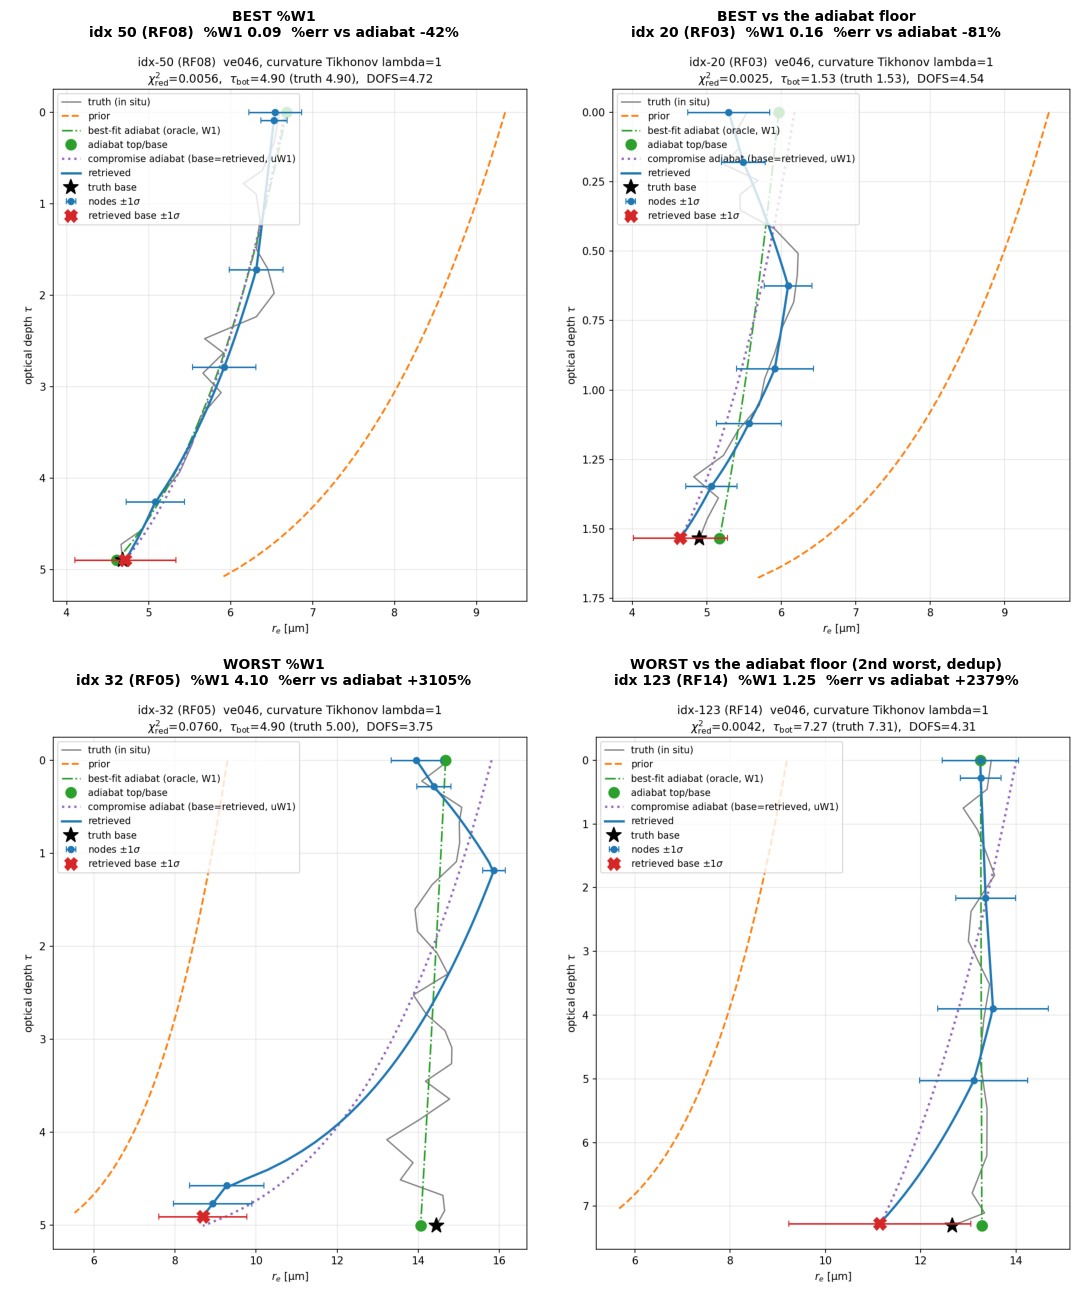

§16 Fig 1 — best and worst retrievals, standard format (green = the truth-fed W1-oracle adiabat = the baseline).


In [4]:
# §16 Fig 1 — best / worst retrieval gallery in the DEFAULT single-profile format
# (scripts/plot_retrieved_profile.py: truth, prior, W1-oracle adiabat, retrieved ±1σ, bases).
# Four panels: best %W1, best vs the adiabat floor, worst %W1, worst vs the floor — falling back
# to the 2nd-ranked floor pick when it coincides with the %W1 pick.
if ROWS and CANON_DIR is not None:
    order_pct = np.argsort(_g(A, 'pct_w1'))
    order_err = np.argsort(PCTERR)
    _lab = lambda i, what: (f"{what}\nidx {A[i]['index']} ({A[i]['flight']})  "
                            f"%W1 {A[i]['pct_w1']:.2f}  %err vs adiabat {PCTERR[i]:+.0f}%"
                            + (f"\n[{PROV_FLAG[A[i]['index']]}]" if A[i]['index'] in PROV_FLAG else ''))
    best, worst = order_pct[0], order_pct[-1]
    bf = order_err[0] if A[order_err[0]]['index'] != A[best]['index'] else order_err[1]
    wf = order_err[-1] if A[order_err[-1]]['index'] != A[worst]['index'] else order_err[-2]
    picks = [(A[best]['index'], _lab(best, 'BEST %W1')),
             (A[bf]['index'], _lab(bf, 'BEST vs the adiabat floor'
                                       + (' (2nd best, dedup)' if bf != order_err[0] else ''))),
             (A[worst]['index'], _lab(worst, 'WORST %W1')),
             (A[wf]['index'], _lab(wf, 'WORST vs the adiabat floor'
                                       + (' (2nd worst, dedup)' if wf != order_err[-1] else '')))]
    profile_montage(picks, ncol=2)
    print('§16 Fig 1 — best and worst retrievals, standard format '
          '(green = the truth-fed W1-oracle adiabat = the baseline).')
elif ROWS:
    print('(gallery skipped: raw bundle not on this machine)')


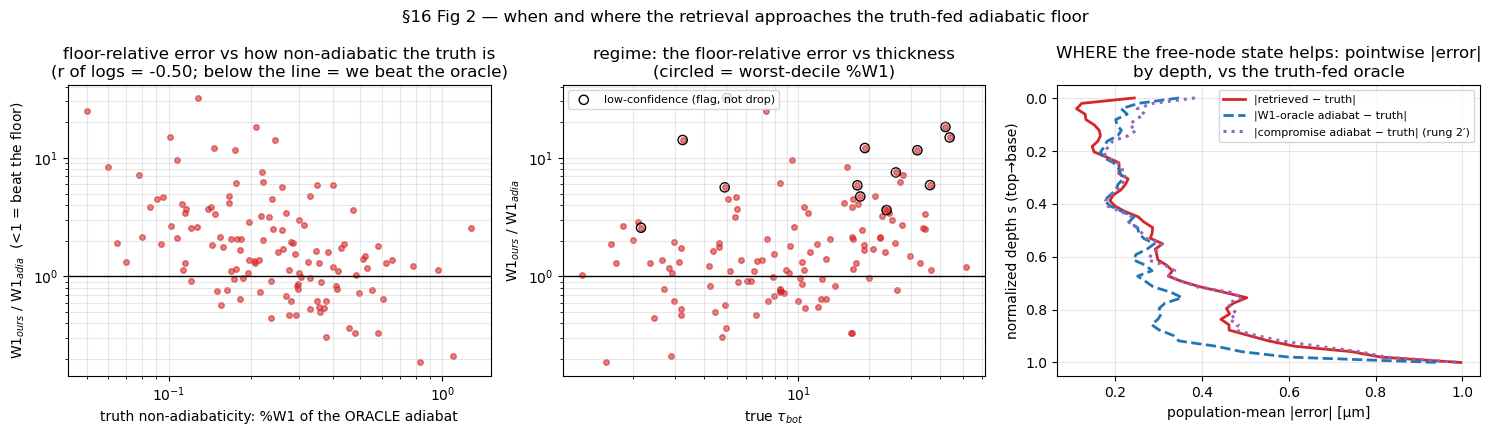

  win rate vs the floor: 29.6% overall; 33.0% excluding low-confidence


In [5]:
# §16 Fig 2 — population structure: WHEN do we approach/beat the floor? (a) W1_ours/W1_adia vs
# the truth's own non-adiabaticity (%W1 of the oracle adiabat); (b) the same ratio vs τ_bot
# (regime + low-confidence); (c) mean |error| vs depth: WHERE in the cloud the free-node
# retrieval helps. Ratio (log scale) below 1 = we beat the truth-fed oracle.
if ROWS:
    LC = {(m[0], m[1]) for m in SUMMARY['flags']['low_confidence']['members']}
    lc_m = np.array([(r['index'], r['config']) in LC for r in A])
    tb = _g(A, 'tau_bot_truth')
    pct_adia = 100.0 * _g(A, 'w1_adia') / tb
    fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
    ax[0].scatter(pct_adia, RATIO, s=16, alpha=.6, color='C3')
    ax[1].scatter(tb, RATIO, s=16, alpha=.6, color='C3')
    ax[1].scatter(tb[lc_m], RATIO[lc_m], s=44, facecolors='none', edgecolors='k',
                  label='low-confidence (flag, not drop)')
    for a in ax[:2]:
        a.axhline(1.0, color='k', lw=1.0); a.set_yscale('log'); a.grid(alpha=.3, which='both')
    _r = np.corrcoef(np.log(pct_adia), np.log(RATIO))[0, 1]
    ax[0].set(xscale='log', xlabel='truth non-adiabaticity: %W1 of the ORACLE adiabat',
              ylabel='W1$_{ours}$ / W1$_{adia}$  (<1 = beat the floor)',
              title=f'floor-relative error vs how non-adiabatic the truth is\n'
                    f'(r of logs = {_r:+.2f}; below the line = we beat the oracle)')
    ax[1].legend(fontsize=8, loc='upper left')
    ax[1].set(xscale='log', xlabel=r'true $\tau_{bot}$', ylabel='W1$_{ours}$ / W1$_{adia}$',
              title='regime: the floor-relative error vs thickness\n(circled = worst-decile %W1)')
    if CANON_DIR is not None:
        SD = eO = eA = eP = None; n = 0
        for r in A:
            d = np.load(CANON_DIR / f"{r['index']}_A.npz", allow_pickle=True)
            s = np.asarray(d['s_dense'], float); SD = s
            tr = np.asarray(d['re_truth_dense'], float)
            re_pin, _ = ra._fit_adiabat_rbase_pinned_uw1(          # rung 2′ (compromise)
                tr, s * float(d['truth_tau_bot']), s, float(d['r_base_ret']))
            eO = (0 if eO is None else eO) + np.abs(np.asarray(d['re_ours_dense'], float) - tr)
            eA = (0 if eA is None else eA) + np.abs(np.asarray(d['re_adia_dense'], float) - tr)
            eP = (0 if eP is None else eP) + np.abs(re_pin - tr)
            n += 1
        ax[2].plot(eO / n, SD, 'C3-', lw=2, label='|retrieved − truth|')
        ax[2].plot(eA / n, SD, 'C0--', lw=2, label='|W1-oracle adiabat − truth|')
        ax[2].plot(eP / n, SD, color='tab:purple', ls=':', lw=2.2,
                   label='|compromise adiabat − truth| (rung 2′)')
        ax[2].invert_yaxis(); ax[2].grid(alpha=.3); ax[2].legend(fontsize=8)
        ax[2].set(xlabel='population-mean |error| [µm]', ylabel='normalized depth s (top→base)',
                  title='WHERE the free-node state helps: pointwise |error|\nby depth, vs the truth-fed oracle')
    else:
        ax[2].set_axis_off(); ax[2].text(.05, .5, 'error-vs-depth needs the raw bundle', fontsize=9)
    fig.suptitle('§16 Fig 2 — when and where the retrieval approaches the truth-fed adiabatic floor',
                 fontsize=12)
    fig.tight_layout(); plt.show()
    print(f'  win rate vs the floor: {np.mean(RATIO < 1):.1%} overall; '
          f'{np.mean(RATIO[~lc_m] < 1):.1%} excluding low-confidence')


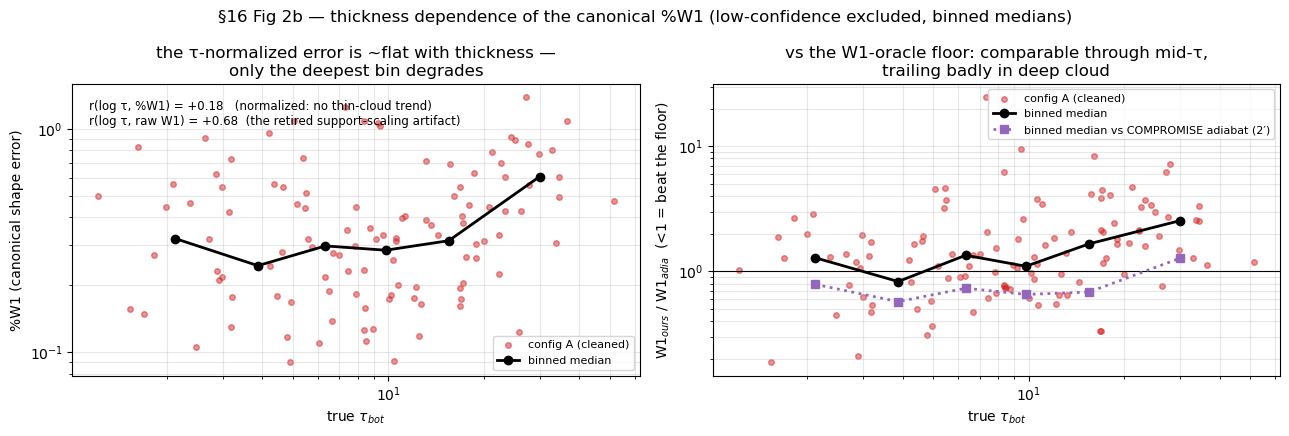

In [6]:
# §16 Fig 2b — thickness dependence under the CANONICAL (τ-normalized) metric, cleaned:
# low-confidence outliers (worst-decile %W1) removed, per-τ_bot binned medians overlaid. NB this figure RETIRES the
# old "thin clouds are retrieved best" reading: that trend lived in the UN-normalized W1, whose
# integral scales with the cloud's own support — normalized, skill is nearly thickness-flat and
# only the deepest regime degrades (both absolutely and relative to the truth-fed oracle floor).
if ROWS:
    LC = {(m[0], m[1]) for m in SUMMARY['flags']['low_confidence']['members']}
    keep = np.array([(r['index'], r['config']) not in LC for r in A])
    tb = _g(A, 'tau_bot_truth')
    edges = np.array([1.5, 3, 5, 8, 12, 20, 45.0]); ctr = np.sqrt(edges[:-1] * edges[1:])
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
    panels = [(_g(A, 'pct_w1'), '%W1 (canonical shape error)',
               'the τ-normalized error is ~flat with thickness —\nonly the deepest bin degrades'),
              (RATIO, 'W1$_{ours}$ / W1$_{adia}$  (<1 = beat the floor)',
               'vs the W1-oracle floor: comparable through mid-τ,\ntrailing badly in deep cloud')]
    for j, (yy, ylab, ttl) in enumerate(panels):
        ax[j].scatter(tb[keep], yy[keep], s=16, alpha=.5, color='C3', label='config A (cleaned)')
        med = [np.median(yy[keep & (tb >= lo) & (tb < hi)])
               if np.any(keep & (tb >= lo) & (tb < hi)) else np.nan
               for lo, hi in zip(edges[:-1], edges[1:])]
        ax[j].plot(ctr, med, 'k-o', lw=2, ms=6, label='binned median', zorder=5)
        ax[j].set(xscale='log', yscale='log', xlabel=r'true $\tau_{bot}$', ylabel=ylab, title=ttl)
        ax[j].grid(alpha=.3, which='both'); ax[j].legend(fontsize=8)
    # the same ratio against the COMPROMISE adiabat (rung 2′): the reachability-honest floor
    ratio_pin = (_g(A, 'pct_w1') * tb / 100.0) / _g(A, 'w1_adia_pin')
    medp = [np.median(ratio_pin[keep & (tb >= lo) & (tb < hi)])
            if np.any(keep & (tb >= lo) & (tb < hi)) else np.nan
            for lo, hi in zip(edges[:-1], edges[1:])]
    ax[1].plot(ctr, medp, color='tab:purple', ls=':', marker='s', lw=2, ms=6, zorder=5,
               label='binned median vs COMPROMISE adiabat (2′)')
    ax[1].legend(fontsize=8)
    ax[1].axhline(1.0, color='k', lw=.8)
    _rn = np.corrcoef(np.log(tb[keep]), _g(A, 'pct_w1')[keep])[0, 1]
    _ra = np.corrcoef(np.log(tb[keep]), (_g(A, 'pct_w1') * tb / 100.0)[keep])[0, 1]
    ax[0].annotate(f'r(log τ, %W1) = {_rn:+.2f}   (normalized: no thin-cloud trend)\n'
                   f'r(log τ, raw W1) = {_ra:+.2f}  (the retired support-scaling artifact)',
                   (.03, .86), xycoords='axes fraction', fontsize=8.5)
    fig.suptitle('§16 Fig 2b — thickness dependence of the canonical %W1 '
                 '(low-confidence excluded, binned medians)', fontsize=12)
    fig.tight_layout(); plt.show()


In [7]:
'''
# §16 Fig 3 — prior-draw luck (A vs B): paired d_W1, the (B−A) distribution, and what a
# "luckier" draw buys: best-of-{A,B} as a 2-restart oracle.
if ROWS:
    ia = {r['index']: r for r in A}; ib = {r['index']: r for r in B}
    common = sorted(set(ia) & set(ib))
    dA = np.array([ia[i]['d_w1'] for i in common]); dB = np.array([ib[i]['d_w1'] for i in common])
    fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))
    lim = [min(dA.min(), dB.min()) - .05, max(dA.max(), dB.max()) + .05]
    ax[0].scatter(dA, dB, s=14, alpha=.6); ax[0].plot(lim, lim, 'k:', lw=1)
    ax[0].axhline(0, color='k', lw=.6); ax[0].axvline(0, color='k', lw=.6)
    ax[0].set(xlabel='d_W1, config A [τ]', ylabel='d_W1, config B [τ]',
              title=f'paired by profile (r={np.corrcoef(dA, dB)[0, 1]:.2f})\nbelow diagonal = the draw hurt')
    ax[1].hist(dB - dA, bins=31, color='C4', alpha=.85)
    ax[1].axvline(0, color='k', lw=.8)
    ax[1].set(xlabel='d_W1(B) − d_W1(A) [τ]',
              title=f'draw effect: median {np.median(dB - dA):+.4f} τ\n'
                    f'p10 {np.percentile(dB - dA, 10):+.3f} / p90 {np.percentile(dB - dA, 90):+.3f}')
    best2 = np.maximum(dA, dB)
    ax[2].ecdf(dA, label=f'A (median {np.median(dA):+.3f})')
    ax[2].ecdf(dB, label=f'B (median {np.median(dB):+.3f})')
    ax[2].ecdf(best2, label=f'best-of-2 (median {np.median(best2):+.3f})')
    ax[2].axvline(0, color='k', lw=.6); ax[2].grid(alpha=.3); ax[2].legend(fontsize=8)
    ax[2].set(xlabel='d_W1 [τ]', ylabel='CDF', title='restart value: best-of-{A,B}\n(what "being lucky" buys)')
    fig.tight_layout(); plt.show()
    LC = {(m[0], m[1]) for m in SUMMARY['flags']['low_confidence']['members']}
    both_lc = [i for i in common if (i, 'A') in LC and (i, 'B') in LC]
    print(f'low-confidence in BOTH configs (profile-intrinsic, not draw luck): {both_lc}')
    if REDRAW is not None:                     # the "+1": the fortune-adjusted 124-B re-draw
        r0 = ib.get(124)
        print(f"124-B, the catastrophic-but-VALID draw (in the 250): d_W1 {r0['d_w1']:+.3f}, "
              f"χ²ᵣ {r0['chi2_red']:.3g}, n_gn {r0['n_gn']}  ->  the +1 RE-DRAW (outside the 250): "
              f"d_W1 {REDRAW['d_w1']:+.3f}, χ²ᵣ {REDRAW['chi2_red']:.3g} — the draw, not the "
              f"machinery, was the failure; cf. config A: d_W1 {ia[124]['d_w1']:+.3f}")
'''

'\n# §16 Fig 3 — prior-draw luck (A vs B): paired d_W1, the (B−A) distribution, and what a\n# "luckier" draw buys: best-of-{A,B} as a 2-restart oracle.\nif ROWS:\n    ia = {r[\'index\']: r for r in A}; ib = {r[\'index\']: r for r in B}\n    common = sorted(set(ia) & set(ib))\n    dA = np.array([ia[i][\'d_w1\'] for i in common]); dB = np.array([ib[i][\'d_w1\'] for i in common])\n    fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))\n    lim = [min(dA.min(), dB.min()) - .05, max(dA.max(), dB.max()) + .05]\n    ax[0].scatter(dA, dB, s=14, alpha=.6); ax[0].plot(lim, lim, \'k:\', lw=1)\n    ax[0].axhline(0, color=\'k\', lw=.6); ax[0].axvline(0, color=\'k\', lw=.6)\n    ax[0].set(xlabel=\'d_W1, config A [τ]\', ylabel=\'d_W1, config B [τ]\',\n              title=f\'paired by profile (r={np.corrcoef(dA, dB)[0, 1]:.2f})\nbelow diagonal = the draw hurt\')\n    ax[1].hist(dB - dA, bins=31, color=\'C4\', alpha=.85)\n    ax[1].axvline(0, color=\'k\', lw=.8)\n    ax[1].set(xlabel=\'d_W1(B) − d_W1(A) [

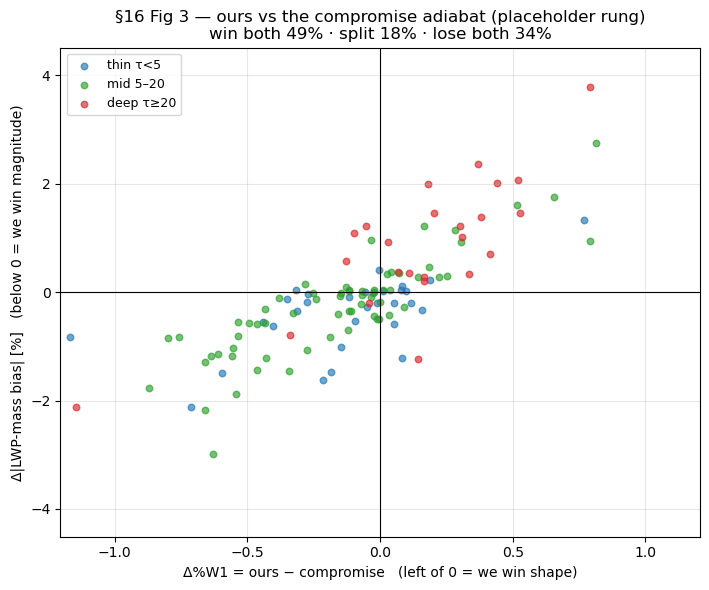

  (axes clipped at the 98th percentile; the far outliers are the usual deep/pathology cases)


In [8]:
# §16 Fig 3 — the COMPROMISE adiabat rung (base pinned to ours, uW1 fit): where do we beat an
# adiabat that shares our base information and cannot decouple shape from mass? Quadrant plane:
# x = our %W1 advantage, y = our |LWP-mass-bias| advantage (both negative = we win both).
# Truth-fed PLACEHOLDER for the k=1 radiance-driven adiabat-class campaign — validate, then retire.
if ROWS:
    tb = _g(A, 'tau_bot_truth')
    pct_pin = 100.0 * _g(A, 'w1_adia_pin') / tb
    mb_ours = 100.0 * (_g(A, 'lwp_ours') / _g(A, 'lwp_truth_tau') - 1)
    mb_pin = 100.0 * (_g(A, 'lwp_pin') / _g(A, 'lwp_truth_tau') - 1)
    dx = _g(A, 'pct_w1') - pct_pin                      # <0 = we win shape
    dy = np.abs(mb_ours) - np.abs(mb_pin)               # <0 = we win LWP
    fig, ax = plt.subplots(figsize=(7.2, 6))
    for lab, m, c in [('thin τ<5', tb < 5, 'C0'), ('mid 5–20', (tb >= 5) & (tb < 20), 'C2'),
                      ('deep τ≥20', tb >= 20, 'C3')]:
        ax.scatter(dx[m], dy[m], s=22, alpha=.65, color=c, label=lab)
    ax.axhline(0, color='k', lw=.8); ax.axvline(0, color='k', lw=.8)
    ax.set(xlabel='Δ%W1 = ours − compromise   (left of 0 = we win shape)',
           ylabel='Δ|LWP-mass bias| [%]   (below 0 = we win magnitude)',
           title='§16 Fig 3 — ours vs the compromise adiabat (placeholder rung)\n'
                 f'win both {np.mean((dx < 0) & (dy < 0)):.0%} · split '
                 f'{np.mean((dx < 0) ^ (dy < 0)):.0%} · lose both {np.mean((dx > 0) & (dy > 0)):.0%}')
    ax.grid(alpha=.3); ax.legend(fontsize=9)
    _m = np.percentile(np.abs(dx), 98); ax.set_xlim(-_m, _m)
    _m = np.percentile(np.abs(dy), 98); ax.set_ylim(-_m, _m)
    fig.tight_layout(); plt.show()
    print('  (axes clipped at the 98th percentile; the far outliers are the usual deep/pathology cases)')


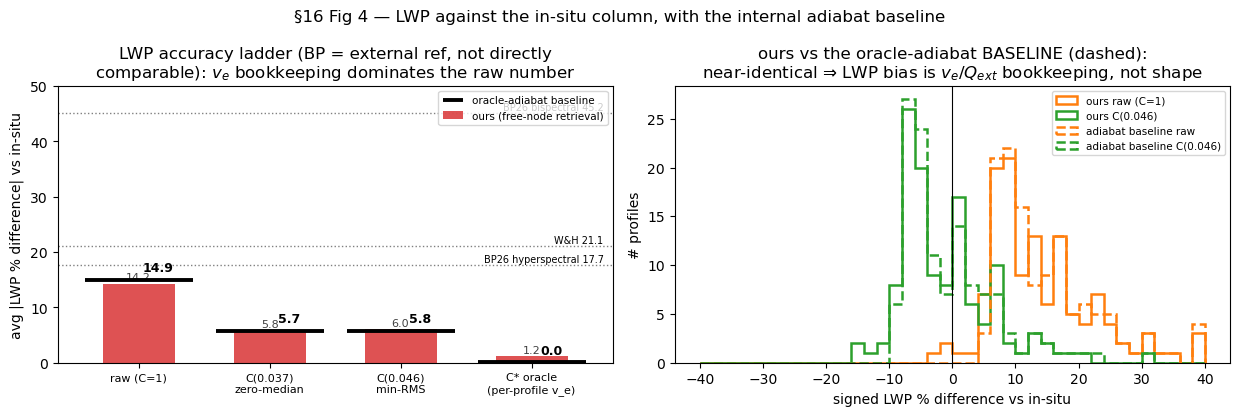

In [9]:
# §16 Fig 4 — LWP: the v_e ladder (post-hoc C-corrections, §5c) with the oracle-adiabat BASELINE
# (bold ink markers + direct value labels, all four rungs incl. C*). BP2025/26 shown as an
# EXTERNAL, not-directly-comparable reference (real-Mie + WV retrieval).
if ROWS:
    fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.2))
    keys = [('lwp_relbias_z', 'raw (C=1)'), ('lwp_relbias_C037', 'C(0.037)\nzero-median'),
            ('lwp_relbias_C046', 'C(0.046)\nmin-RMS'), ('lwp_relbias_Coracle', 'C* oracle\n(per-profile v_e)')]
    akeys = ['lwp_relbias_adia_z', 'lwp_relbias_adia_C037', 'lwp_relbias_adia_C046', 'lwp_relbias_adia_Coracle']
    xs = np.arange(len(keys)); w = 0.55
    bars = ax[0].bar(xs, [np.nanmean(np.abs(_g(A, k))) for k, _ in keys], w,
                     color='C3', alpha=.8, label='ours (free-node retrieval)')
    ax[0].bar_label(bars, fmt='%.1f', fontsize=8, padding=1, color='0.25')
    # oracle-adiabat baseline: adiabat fit to the truth carries the same width/Q_ext artifact;
    # bold ink marker spanning each bar + a direct value label, so the reference is unambiguous.
    base = [np.nanmean(np.abs(_g(A, ak))) for ak in akeys]
    ax[0].hlines(base, xs - .75 * w, xs + .75 * w, colors='k', lw=2.8, zorder=6,
                 label='oracle-adiabat baseline')
    for x, b in zip(xs, base):
        ax[0].annotate(f'{b:.1f}', (x, b), xytext=(14, 4), textcoords='offset points',
                       ha='center', va='bottom', fontsize=9, fontweight='bold', color='k', zorder=7)
    for y, t in [(45.2, 'BP26 bispectral 45.2'), (21.1, 'W&H 21.1'), (17.7, 'BP26 hyperspectral 17.7')]:
        ax[0].axhline(y, color='gray', ls=':', lw=1)
        ax[0].text(len(keys) - .45, y + .5, t, fontsize=7, ha='right')
    ax[0].set_xticks(xs); ax[0].set_xticklabels([t for _, t in keys], fontsize=8)
    ax[0].set_xlim(-.62, len(keys) - .38); ax[0].set_ylim(0, 50)
    ax[0].set(ylabel='avg |LWP % difference| vs in-situ',
              title='LWP accuracy ladder (BP = external ref, not directly\ncomparable): $v_e$ bookkeeping dominates the raw number')
    ax[0].legend(fontsize=7.5, loc='upper right')
    bins = np.linspace(-40, 40, 41)
    for k, lab, c, ls in [('lwp_relbias_z', 'ours raw (C=1)', 'C1', '-'),
                          ('lwp_relbias_C046', 'ours C(0.046)', 'C2', '-'),
                          ('lwp_relbias_adia_z', 'adiabat baseline raw', 'C1', '--'),
                          ('lwp_relbias_adia_C046', 'adiabat baseline C(0.046)', 'C2', '--')]:
        ax[1].hist(np.clip(_g(A, k), -40, 40), bins=bins, histtype='step', lw=1.8, color=c, ls=ls, label=lab)
    ax[1].axvline(0, color='k', lw=.8); ax[1].legend(fontsize=7.5)
    ax[1].set(xlabel='signed LWP % difference vs in-situ', ylabel='# profiles',
              title='ours vs the oracle-adiabat BASELINE (dashed):\nnear-identical ⇒ LWP bias is $v_e$/$Q_{ext}$ bookkeeping, not shape')
    fig.suptitle('§16 Fig 4 — LWP against the in-situ column, with the internal adiabat baseline', fontsize=12)
    fig.tight_layout(); plt.show()


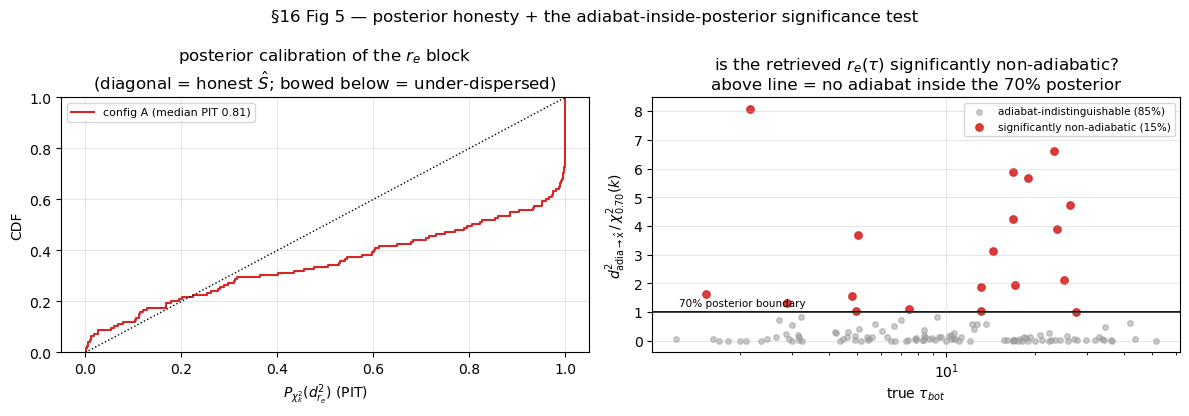

  thin τ<5   n= 32: significantly non-adiabatic  16%
  mid 5–20   n= 66: significantly non-adiabatic  14%
  deep τ≥20  n= 27: significantly non-adiabatic  19%
  overall: 15% significant at 70% — for the other 85% an adiabat sits inside the 70% posterior (adiabat-compatible at our uncertainty)
  (NB the k=2 give-up grids idx 49/57 are adiabat-representable by construction)


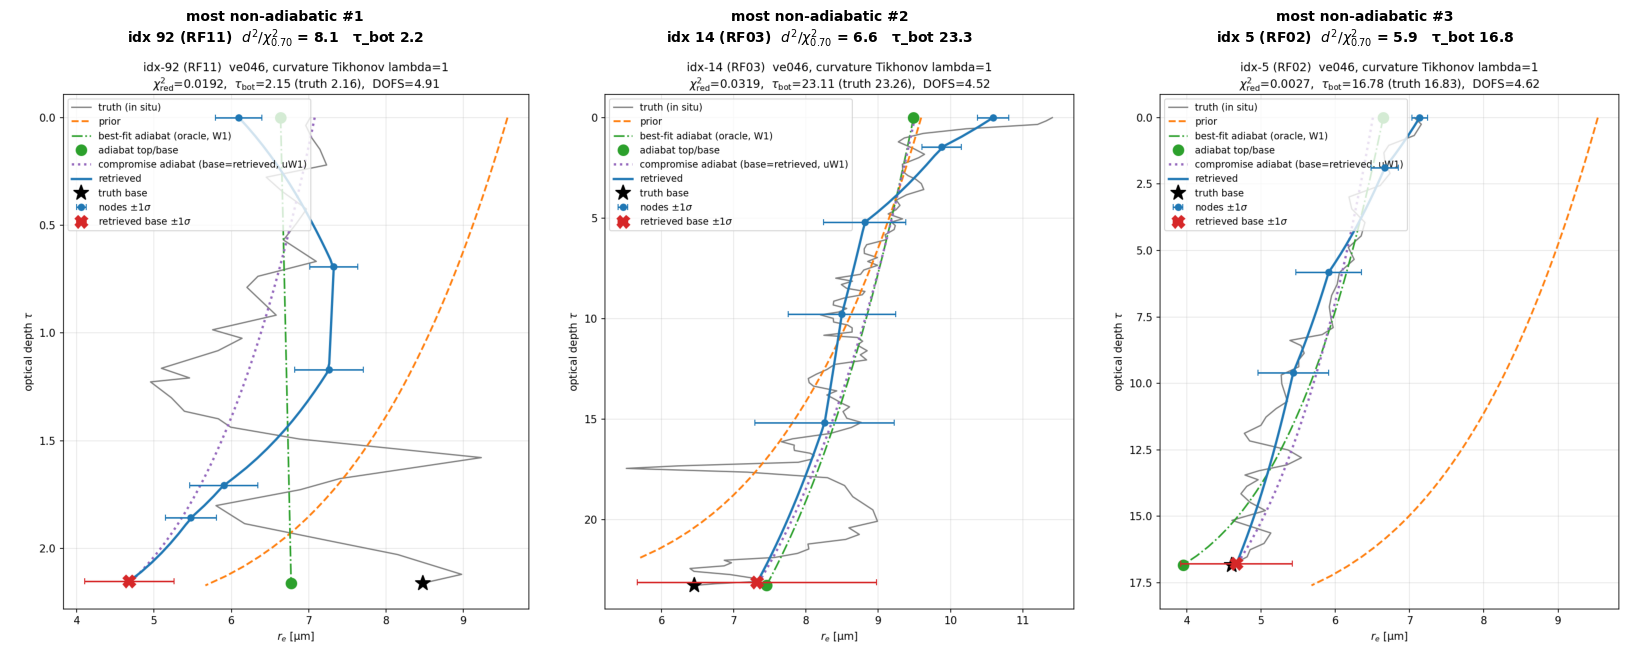

§16 Fig 5b — the three most significantly non-adiabatic retrievals (standard format).


In [10]:
# §16 Fig 5 — is the posterior honest, and is the retrieved profile significantly non-adiabatic?
# (left)  posterior calibration of the r_e block: PIT of d²_re under χ²_k (diagonal = honest Ŝ).
# (right) SIGNIFICANCE test — the closest adiabat to our ESTIMATE x̂, in units of the 70%
#         posterior ellipsoid (χ²_{0.70}(k); threshold per user 2026-07-15). Above 1 ⇒ no
#         adiabat fits inside the 70% posterior ⇒ the retrieved r_e(τ) is distinguishable from
#         every adiabat at that confidence, given our own uncertainty. Linear y — most points
#         cluster toward 0 (deeply adiabat-compatible), which is itself the message.
if ROWS:
    from scipy import stats as sst
    CONF = 0.70
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
    d2 = _g(A, 'd2_re'); kk = _g(A, 'k').astype(int)
    pit = np.array([sst.chi2.cdf(d, k) for d, k in zip(d2, kk)])
    ax[0].ecdf(pit[np.isfinite(pit)], color='C3', label=f'config A (median PIT {np.nanmedian(pit):.2f})')
    ax[0].plot([0, 1], [0, 1], 'k:', lw=1)
    ax[0].set(xlabel=r'$P_{\chi^2_k}(d^2_{r_e})$ (PIT)', ylabel='CDF',
              title='posterior calibration of the $r_e$ block\n(diagonal = honest $\\hat S$; bowed below = under-dispersed)')
    ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
    # right: adiabat-inside-posterior significance at the 70% level, resolved by regime
    tb = _g(A, 'tau_bot_truth')
    thr = np.array([sst.chi2.ppf(CONF, k) for k in kk])
    ratio70 = _g(A, 'd2_adia_xhat') / thr
    sig = ratio70 > 1.0
    ax[1].scatter(tb[~sig], ratio70[~sig], s=16, alpha=.5, color='0.6',
                  label=f'adiabat-indistinguishable ({(~sig).mean():.0%})')
    ax[1].scatter(tb[sig], ratio70[sig], s=28, alpha=.9, color='C3',
                  label=f'significantly non-adiabatic ({sig.mean():.0%})')
    ax[1].axhline(1.0, color='k', lw=1.3, zorder=1)
    ax[1].text(tb.min() * 1.02, 1.12, f'{CONF:.0%} posterior boundary', fontsize=7.5, va='bottom')
    ax[1].set(xscale='log', xlabel=r'true $\tau_{bot}$',
              ylabel=fr'$d^2_{{\rm adia\to\hat{{x}}}}\,/\,\chi^2_{{{CONF:.2f}}}(k)$',
              title='is the retrieved $r_e(\\tau)$ significantly non-adiabatic?\n'
                    f'above line = no adiabat inside the {CONF:.0%} posterior')
    ax[1].grid(alpha=.3); ax[1].legend(fontsize=7.5, loc='upper right')
    fig.suptitle('§16 Fig 5 — posterior honesty + the adiabat-inside-posterior significance test',
                 fontsize=12)
    fig.tight_layout(); plt.show()
    for lab, m in [('thin τ<5', tb < 5), ('mid 5–20', (tb >= 5) & (tb < 20)), ('deep τ≥20', tb >= 20)]:
        print(f'  {lab:10s} n={int(m.sum()):>3}: significantly non-adiabatic {sig[m].mean():>4.0%}')
    print(f'  overall: {sig.mean():.0%} significant at {CONF:.0%} — for the other {1 - sig.mean():.0%} '
          f'an adiabat sits inside the {CONF:.0%} posterior (adiabat-compatible at our uncertainty)')
    print(f'  (NB the k=2 give-up grids idx 49/57 are adiabat-representable by construction)')
    # the three most non-adiabatic clouds, in the DEFAULT single-profile format
    if CANON_DIR is not None:
        top3 = np.argsort(ratio70)[-3:][::-1]
        profile_montage([(A[i]['index'],
                          f"most non-adiabatic #{j + 1}\nidx {A[i]['index']} ({A[i]['flight']})  "
                          f"$d^2/\\chi^2_{{0.70}}$ = {ratio70[i]:.1f}   τ_bot {tb[i]:.1f}")
                         for j, i in enumerate(top3)], ncol=3)
        print('§16 Fig 5b — the three most significantly non-adiabatic retrievals (standard format).')


### §16 Findings — the capstone, on the canonical ve046tik set (125 config-A profiles)

*Primary metrics: profile **shape** = $\%W_1$ (τ-normalized Wasserstein of the $r_e$-mass density, % of the cloud's own $\tau_{\rm bot}$); vs the truth-fed, $W_1$-fit adiabat = **percentage error against the baseline**; **magnitude** = LWP-bias. RMSE retired 2026-07-08; un-normalized $W_1$ retired 2026-07-11.*

1. **The measurement does overwhelming work.** Medians: the no-retrieval prior baseline sits at $\%W_1$ = **27.5**; a truth-fed *constant* gets to 2.9; the free-node retrieval reaches **$\%W_1$ = 0.39** — a factor ~70 below the prior and ~7.5× below the 1-DOF constant — with $\chi^2_r$ at the representation floor (median 0.0029) and **$\tau_{\rm bot}$ to −0.1% median**. Against the 2-DOF oracle floor ($\%W_1$ = 0.24) the headline is honest and humbling: **median %err = +60% (win rate 30%)**. The near-tie of the batch-3 analysis does **not** carry over, largely because the floor got harder: the oracle adiabat is now fit by *minimizing $W_1$ itself* (metric-matched), where the old floor was an RMSE-fit adiabat scored in $W_1$. In absolute terms the gap is small — +60% of a 0.24% floor ≈ 0.15% of $\tau_{\rm bot}$.

2. **We approach/beat the floor exactly where there is non-adiabatic structure to resolve.** The floor-relative error is strongly anti-correlated with the truth's own non-adiabaticity ($r$ of logs = **−0.50**, Fig 2a): for near-adiabatic truths the oracle is nearly perfect and *cannot* be beaten (trailing it there costs ~nothing absolutely), while for the most non-adiabatic clouds the retrieval wins outright (best cases idx 20/35/19: %err −81/−79/−69). Pointwise (Fig 2c), the free-node state beats the oracle at the **cloud top** (mean |err| 0.15 vs 0.22 µm for s<0.2) and trails below s≈0.6 with the base spike — the depth-shielding limit, unchanged.

3. **The "thin clouds are retrieved best" finding is retired** (it did not survive the normalized metric — the rigorous coordinate change, not a new result, killed it). The old trend lived in the *un-normalized* $W_1$, whose integral scales with the cloud's own support: $r(\log\tau_{\rm bot}, W_1^{\rm raw})$ = +0.68 (cleaned) versus $r(\log\tau_{\rm bot}, \%W_1)$ = **+0.18** (cleaned; +0.14 full) — flat (Fig 2b). What survives is a **deep-cloud penalty**: for τ≥20, median $\%W_1$ doubles (0.77 vs ~0.32 mid-range) and the floor-relative error blows out (median %err +197%, win 4%, vs +25%/38% thin) — ill-posedness at depth, concentrated in the regime where no radiance reaches.

4. **The low-confidence tail (13 of 125, worst-decile $\%W_1$ ≥ 1.43).** *Flag rebased 2026-07-16: the earlier worst-decile-$d_{W_1}$ criterion was in absolute τ units — support-scaled, so a thin cloud could never trip it however poor its fit (idx 92, the 4th-worst $\%W_1$, escaped at $\tau_{\rm bot}$≈2.2). The flag now lives on the canonical $\%W_1$.* Members, worst first: idx 32 (4.10), 119 (3.79, the τ≈42 "fits-perfectly, deep-shape-unobserved" watch case), 57 (3.46), 92 (3.29), 54 (2.34), 29, 13, 28, 110, 11, 36, 42, 41 (1.46). Still deep-heavy (median $\tau_{\rm bot}$ ≈ 19 vs population ≈ 10; 6 of 13 at τ≥20) but no longer deep-only — the thin members are precisely the known hard cases: idx 92 and the pathology records idx 57/54/32. $\chi^2_r$ sits at or near the floor throughout: good data-fit, untrustworthy profile. Excluding the tail: median %err vs the floor +36%, win 33%. Note the worst *floor-relative* errors (idx 32 +3105%, 123 +2379%, 119 +1720%) are not all flagged — idx 123's $\%W_1$ is a mid-pack 1.25 against a near-adiabatic truth whose oracle floor is nearly perfect, so a huge %err there costs little in absolute shape. Flagged, not dropped.

5. **LWP — the strongest headline, with the internal baseline.** Avg |%| vs in-situ $\int$LWC dz: raw (C=1) **14.2%** (signed median +12.1% — the $Q_{\rm ext}=2$/width artifact); §5c constant-width correction **C(0.037): 5.8% (signed median −0.0%)**, C(0.046): 6.0%; per-profile oracle C\*: **1.2%**. The oracle-adiabat **baseline** carries the *same* bias (raw 14.9%, C(0.037) 5.7%, C\* 0.0%) — the LWP error is width/$Q_{\rm ext}$ **bookkeeping, not retrieval-shape error** (Fig 4, dashed ≈ solid). External, not-directly-comparable: BP2026 bispectral 45.2%, W&H 21.1%, hyperspectral 17.7%.

6. **Health + UQ honesty.** One `converged=False` (idx 1, iteration cap on $\chi^2_r$ = 0.003 — a technicality); the two structural-misfit flags are the *accepted* pathology-3 picks idx 49/57 ($\chi^2_r$ 0.18/0.14, true-τ_bot-fed prior provenance); **no profile touches the $r_e$ = 22 µm table ceiling**. Posterior calibration (Fig 5 left): the $r_e$-block PIT sits high (median **0.81**) and heavy-right-tailed — **~42% of truths fall outside the 95% posterior ellipsoid**: the Rodgers $\hat S$ omits the representation/regularization bias (§13b), which dominates at depth; report $\hat\sigma$ with that caveat. The adiabat-inside-posterior significance test at the **70% level** (Fig 5 right): **15% of clouds are significantly non-adiabatic** (no adiabat inside the 70% posterior) — and the effect is now nearly regime-flat (thin 16% / mid 14% / deep 19%), unlike the 95% test (9% overall, deep-skewed). The three most significant cases (Fig 5b) include a genuinely thin cloud — idx 92 (τ≈2.2, $d^2/\chi^2_{0.70}$ = 8.1; also a low-confidence member, so read it as "no adiabat fits its posterior", not as trust in its profile detail) — alongside idx 14 (τ≈23) and idx 5 (τ≈17). (The k=2 give-up grids, idx 49/57, are adiabat-representable by construction and cannot fire this test.)

7. **The compromise-adiabat rung (placeholder).** Pinning the adiabat's base to *our retrieved* $r_{\rm base}$ and fitting the one remaining knob under the **un-normalized** $W_1$ (so shape and LWP must share it) converts the untouchable oracle into a beatable, reachability-honest reference: medians (%W1 / |LWP-mass bias|) — compromise 0.50 / 0.8% vs ours 0.39 / 0.5%; **we win both components on 50% of clouds and lose both on 34%** (win-both 56%/64% thin/mid, 11% deep). Its parameter-free brackets quantify the coupling the free oracle escapes: shape-parity with the oracle costs it ~7% median LWP (idx 32: −38%), LWP-parity costs ~2.3× the oracle's shape error. *Caveats: truth-fed (τ-uniform weighting, not radiance-weighted) and anchored to our own base estimate — a diagnostic stand-in, to be validated against and likely retired for the radiance-driven k=1 adiabat-class campaign.*

**Bottom line.** On the self-consistent corrected-width OSSE, the multi-angle 10-band system retrieves *what is physically retrievable*: $\tau_{\rm bot}$ to −0.1%, width-corrected LWP at ~6% (indistinguishable from a perfect-shape adiabat's bookkeeping), and profile shape at $\%W_1$ ≈ 0.4 — ~70× better than the climatology prior, beating the truth-fed $W_1$-oracle adiabat precisely where the truth is non-adiabatic, and trailing it where the truth is nearly adiabatic (unbeatable by construction) or deep (unobservable by physics). *Caveats: noiseless OSSE, no above-cloud water-vapor retrieval, $Q_{\rm ext}=2$ self-consistency; idx 49/54/57 carry the true-τ_bot-fed-prior provenance flag; curvature Tikhonov λ=1.0 throughout.*